# Estudio dqdv y ajustes sobre 10°C


In [6]:
# === Configuración para importar módulos locales ===
import sys
from pathlib import Path

src_path = Path().resolve().parent / "src"
sys.path.append(str(src_path))

print(f"✅ Módulos importados desde: {src_path}")

import processing as pr
import deriv as dr
import plotting as pl
import fitting as ft
import utils_deriv as utl


✅ Módulos importados desde: /home/mariajose/proc-icdv/src


In [7]:
import numpy as np
import pandas as pd
from importlib import reload
from datetime import datetime, timedelta, timezone

In [8]:
# --- carga de datos ---
nombre = 'NMC-10-cada3'
path_json = f"../tmp/{nombre}.json"
dict_ciclos_sep = pr.cargar_json(path_json)
indices_ciclos = list(dict_ciclos_sep.keys())


Estructura: dict_ciclos_sep = {ciclo: {"Ch": df_ciclo_ch, "Dis": df_ciclo_dis}}
Total de ciclos en el JSON: 67


## Gráficos para observar dataset

In [9]:
# --- Selección de ciclos ---
ciclos_sel_todos = pr.seleccionar_ciclos(
    dict_ciclos_sep,
    #rango=(21, 900),
    #excluir={30, 32, 34, 35, 38, 88, 186, 187, 188, 189, 190, 191, 192, 193, 202, 247, 344, 899, 898, 897, 900},
)

✅ 66 ciclos seleccionados
   → [1, 3, 6, 9, 12, 15, 18, 21, 24, 27, 30, 33, 36, 39, 42, 45, 48, 51, 54, 57, 60, 63, 66, 69, 72, 75, 78, 81, 84, 87, 90, 93, 96, 99, 102, 105, 108, 111, 114, 117, 120, 123, 126, 129, 132, 135, 138, 141, 144, 147, 150, 153, 156, 159, 162, 165, 168, 171, 174, 177, 180, 183, 186, 189, 192, 195]


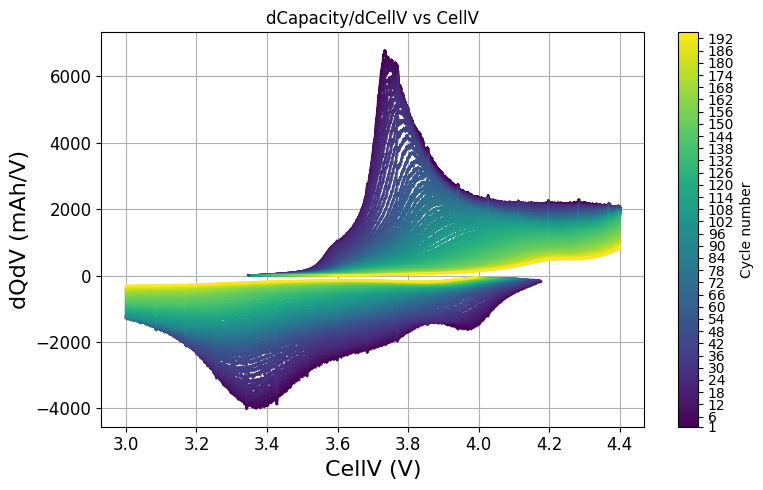

In [10]:
pl.plot_n_cycles_dqdv(ciclos_sel_todos, dict_ciclos_sep)


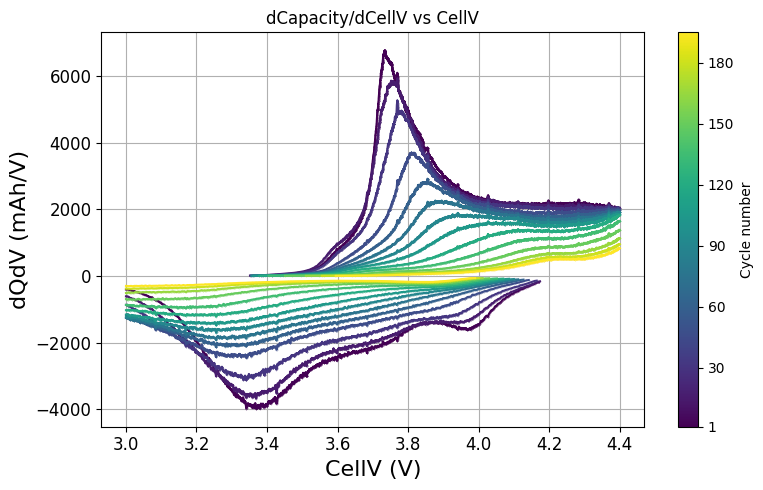

In [11]:
ciclos_sel_grafico = [ciclos_sel_todos[i] for i in range(len(ciclos_sel_todos)) if i % 5 == 0]

pl.plot_n_cycles_dqdv(ciclos_sel_grafico, dict_ciclos_sep)

Gráfico: salto promedio de voltaje (ΔV) entre puntos consecutivos. Resolución (r=1/ΔV) normalizada al ciclo de mayor resolución.


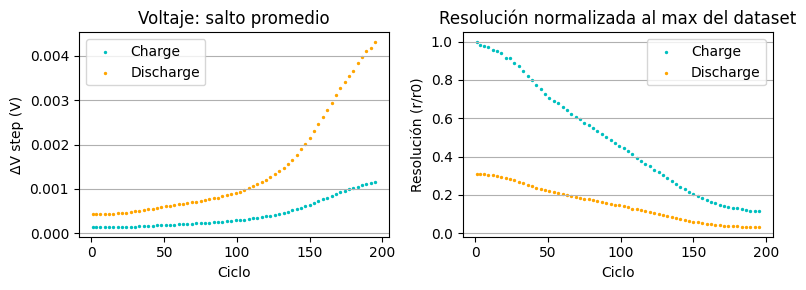

Puntos promedio por ventana de 2 mV:


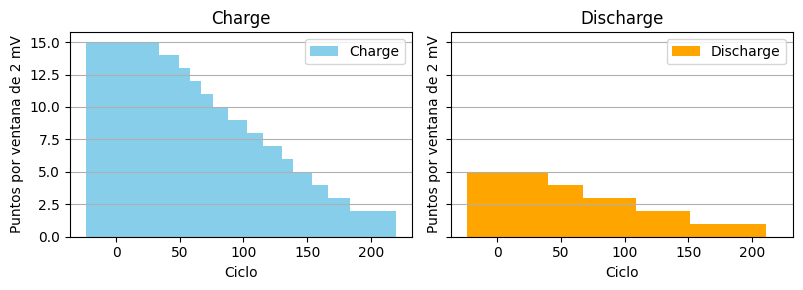

In [12]:
# --- Vemos resolución datos ---

utl.resolucion_V(ciclos_sel_todos, dict_ciclos_sep)

#utl.resolucion_Q(ciclos_sel_todos, dict_ciclos_sep)

## Pruebo parametros filtros para calcular derivada

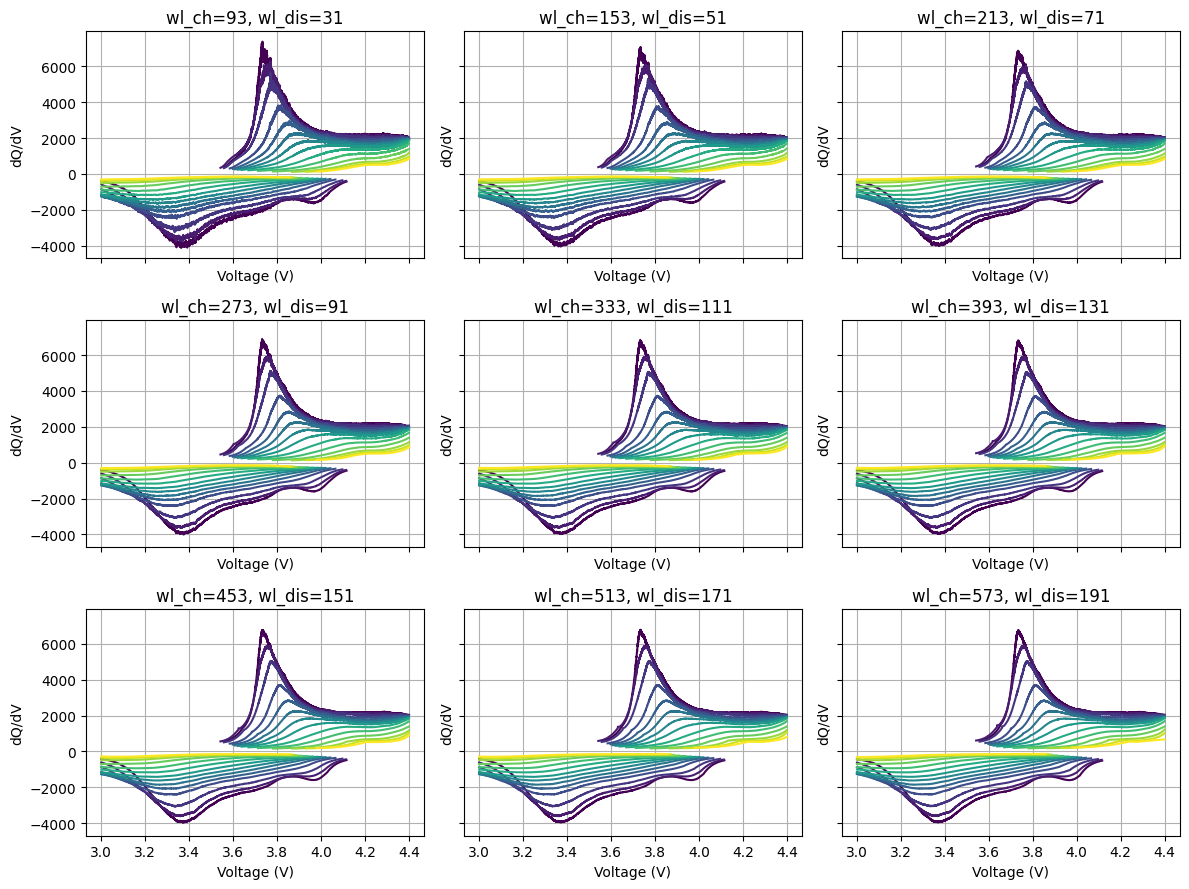

In [13]:
dr.plot_dqdv_muchos_wl(ciclos_sel_grafico, dict_ciclos_sep, wl_values=[31,51,71,91,111,131,151,171,191], truncar_values=(20,60))

## Calculo derivada con los parámetros dados

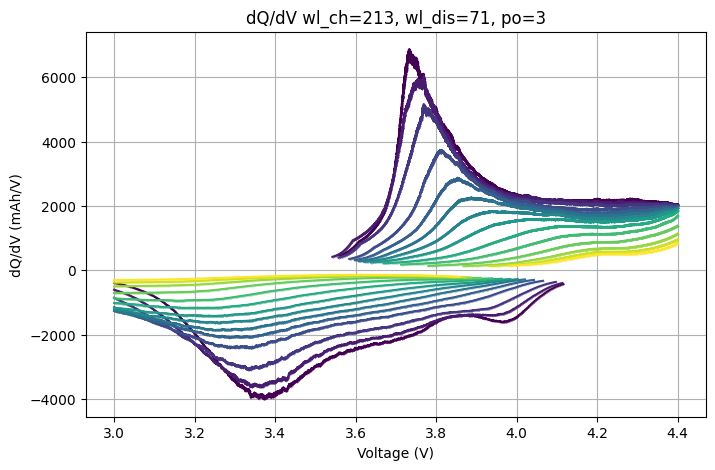

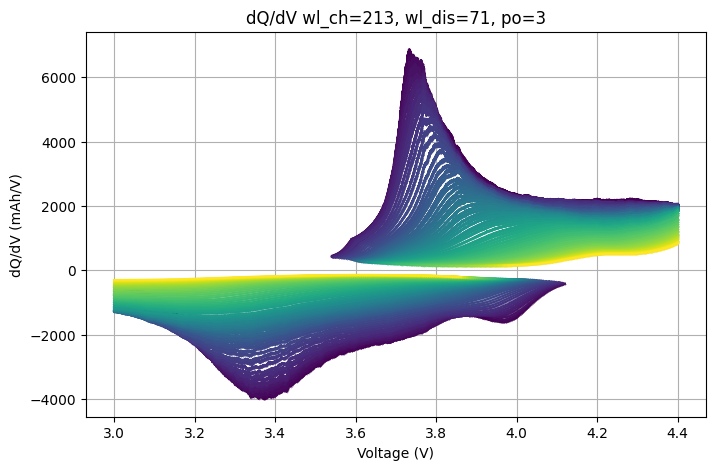

In [14]:
# --- Trunco datos y calculo derivada ---


# --- Parámetros para el cálculo de la derivada ---
# En este conjunto de datos, la señal de carga tiene 3 veces mas resolución que la de descarga.
# Estos valores pueden cambiar según el dataset.

# Para NMC-20:
#   charge (wl = 153, truncar los n=30 puntos iniciales)
#   discharge (wl = 51 = 153 / 3, truncar los n=10=30/3 puntos finales)

# Para NMC-10:
#   charge (wl = 213, truncar los n=30 puntos iniciales)
#   discharge (wl = 71 = 153 / 3, truncar los n=10=30/3 puntos finales)



# --- Calculo derivada dQdV ---

diccio_grafico = {
    ciclo: {
        'Ch': df['Ch'].copy(),
        'Dis': df['Dis'].copy()
    }
    for ciclo, df in dict_ciclos_sep.items()
}

diccio_grafico = dr.truncar_señal(ciclos_sel_grafico, diccio_grafico, n_dis=20, n_ch=60)
diccio_grafico =  dr.plot_dqdV(ciclos_sel_grafico, diccio_grafico, wl_dis=71, wl_ch=213)


diccio_todos = {
    ciclo: {
        'Ch': df['Ch'].copy(),
        'Dis': df['Dis'].copy()
    }
    for ciclo, df in dict_ciclos_sep.items()
}
    
diccio_todos = dr.truncar_señal(ciclos_sel_todos, diccio_todos, n_dis=20, n_ch=60)
diccio_todos =  dr.plot_dqdV(ciclos_sel_todos, diccio_todos, wl_dis=71, wl_ch=213)

# --- Exportar a csv para trabajar en Origin ---
#dict[21]['Ch'].to_csv(output_folder / 'df_ch_21.csv', index=False)
#dict[21]['Dis'].to_csv(output_folder / 'df_dis_21.csv', index=False)

# AJUSTES

In [15]:
# Indices de ciclos disponibles (todos):
# [1, 3, 6, 9, 12, 15, 18, 21, 24, 27, 30, 33, 36, 39, 42, 45, 48, 51, 54, 57, 60, 63, 66, 69, 72, 75, 78, 81, 84, 87, 90, 93, 96, 99, 102, 105, 108, 111, 114, 117, 120, 123, 126, 129, 132, 135, 138, 141, 144, 147, 150, 153, 156, 159, 162, 165, 168, 171, 174, 177, 180, 183, 186, 189, 192, 195]

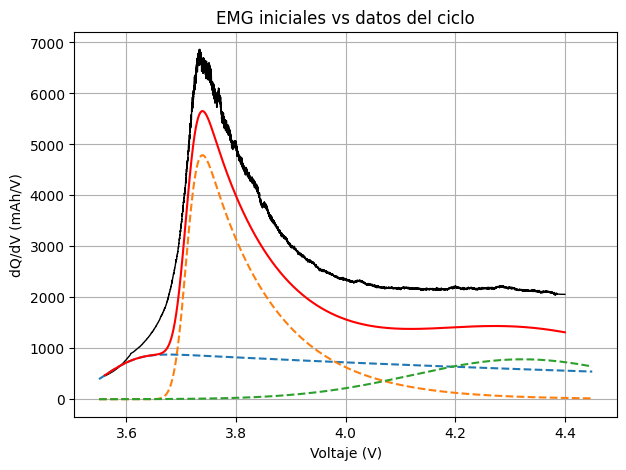

In [16]:
# --- Pruebo manualmente guess inicial para parametros de ajuste ---

# En la EMG los parámetros son: (amplitud, media, sigma, lambda)

df_ch = diccio_todos[1]['Ch']

param_guess = [(1500, 3.56, 5.15620917e-02, 6.37474532e-01),
                ( 7.95488829e+02, 3.71021028e+00, 1.75009098e-02, 8.04841702e+00),
                #(2.12087703e+02, 3.99801493e+00, 2.48713898e-02, 5.36805383e-01),
                (3.95158095e+02, 4.30488376e+00, 2.00453430e-01, 5.51398592e+01)
                ]

ft.plot_emg_guess(df_ch, param_guess, x_range=(3.55, 4.45),legend=False)

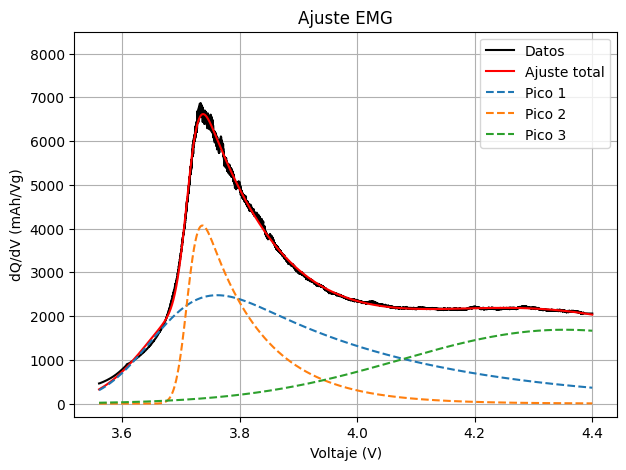

Parámetros optimizados ciclo 1 carga:
[1.18753014e+03 3.66000000e+00 7.35836510e-02 3.22076265e+00
 5.50465186e+02 3.71184184e+00 1.56909474e-02 1.01915061e+01
 1.24530884e+03 4.20488376e+00 2.44995331e-01 5.07781320e+00]


In [18]:
# --- Test de ajuste del primer ciclo ---

# Parámetros iniciales por pico
# Formato: (amplitud, media, sigma, lambda)
p_ini_peaks = [(2.55731493e+03, 3.61000000e+00, 5.16592298e-02, 7.74918978e-01),
                (7.88127408e+02, 3.71032062e+00, 1.77322114e-02, 8.22465006e+00),
                #(2.12087703e+02, 3.99801493e+00, 2.48713898e-02, 5.36805383e-01),
                (5.22420960e+02, 4.25488376e+00, 1.98977731e-01, 1.17940762e+01)
                ]

n_peaks = len(p_ini_peaks)

# Construir p_ini_emg y bounds automáticamente
p_ini_emg = []
lb, ub = [], []

for a0, mu0, sigma0, lam0 in p_ini_peaks:
    p_ini_emg += [a0, mu0, sigma0, lam0]
    lb += [0, mu0-0.05, 1e-6, 0]
    ub += [np.inf, mu0+0.05, np.inf, lam0*10]

bounds_emg = (lb, ub)

# Ajuste del ciclo 1 de carga
df_ch_1 = diccio_todos[1]['Ch']
p_opt_1, cov_1 = ft.fit_emg_ciclo(df_ch_1, p_ini_emg, bounds_emg)
ft.plot_emg_fit(df_ch_1, p_opt_1)

print("Parámetros optimizados ciclo 1 carga:")
print(p_opt_1)

## Loop

In [19]:
reload(ft)

<module 'fitting' from '/home/mariajose/proc-icdv/src/fitting.py'>

In [20]:
timestamp = datetime.now(timezone(timedelta(hours=-3))).strftime("%Y-%m-%d_%H-%M-%S")

cfg_bounds: {'perc_a': 0.9, 'perc_mu': 0.9, 'perc_sigma': 0.9, 'perc_lambda': 0.9}
----------------------------------------
Ajustando ciclo 1...


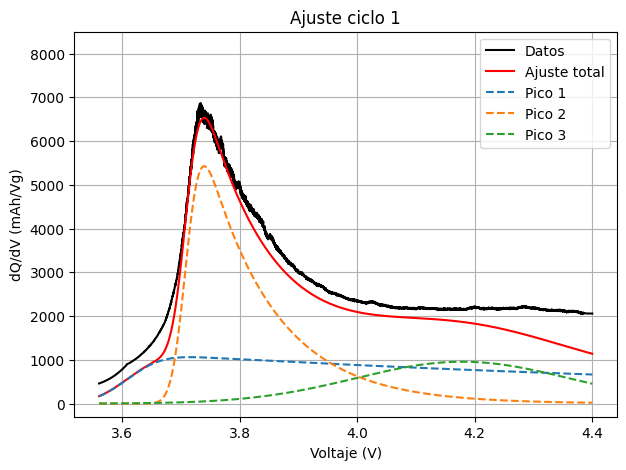

Ajustando ciclo 3...


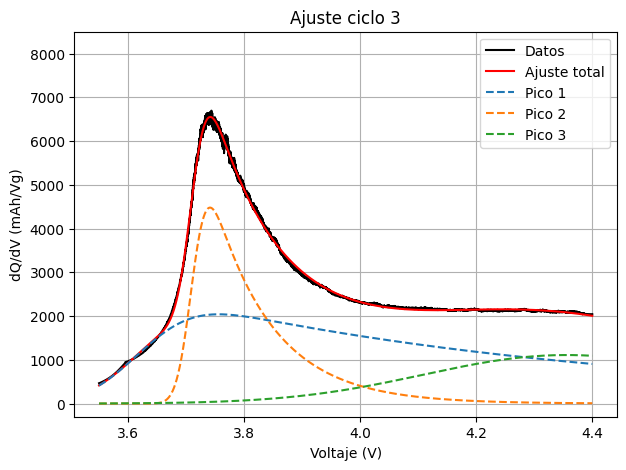

Ajustando ciclo 6...


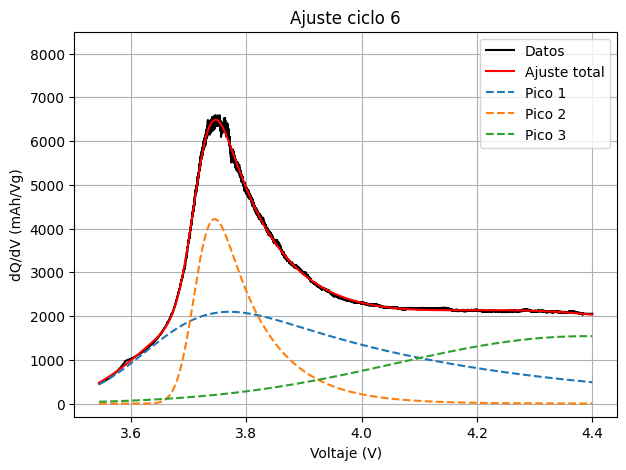

Ajustando ciclo 9...


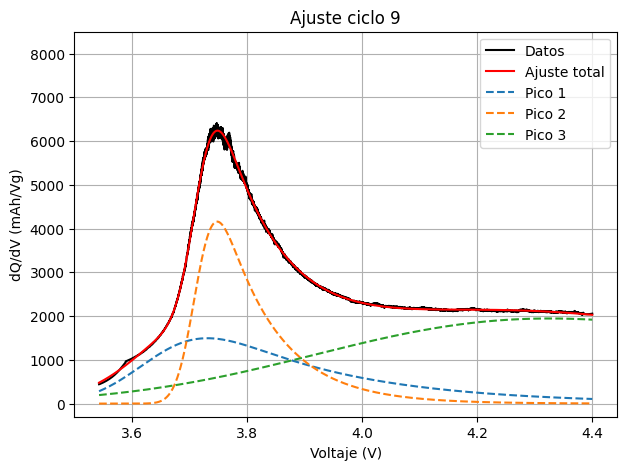

Ajustando ciclo 12...


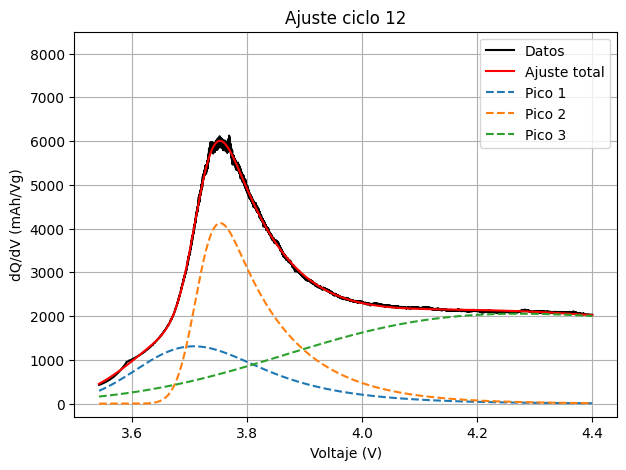

Ajustando ciclo 15...


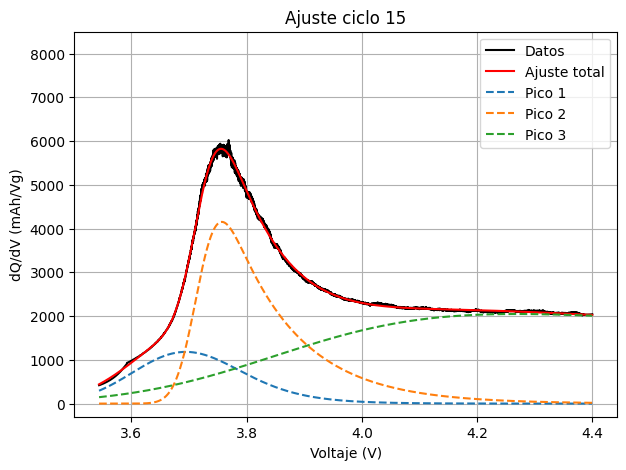

Ajustando ciclo 18...


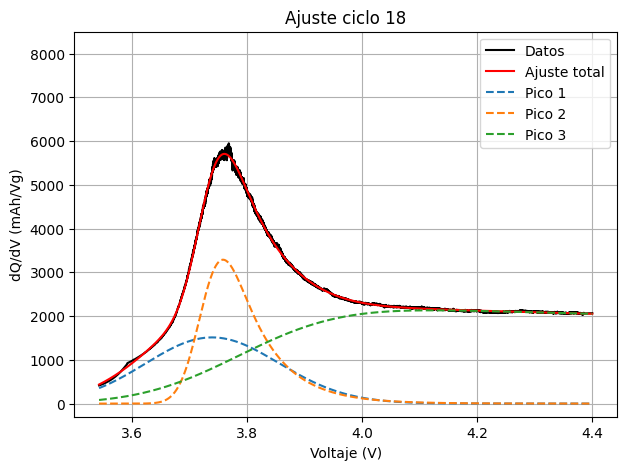

Ajustando ciclo 21...


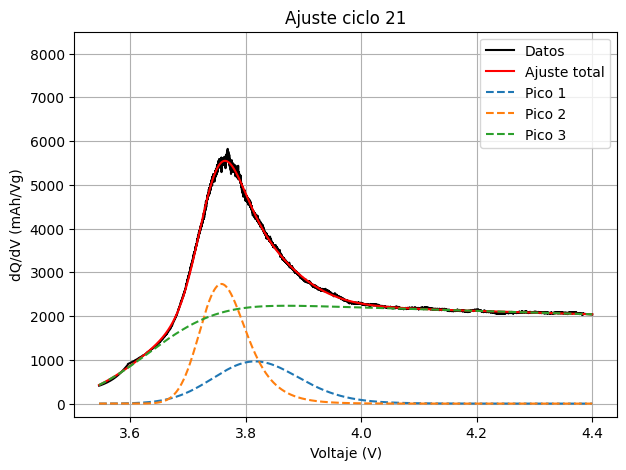

Ajustando ciclo 24...


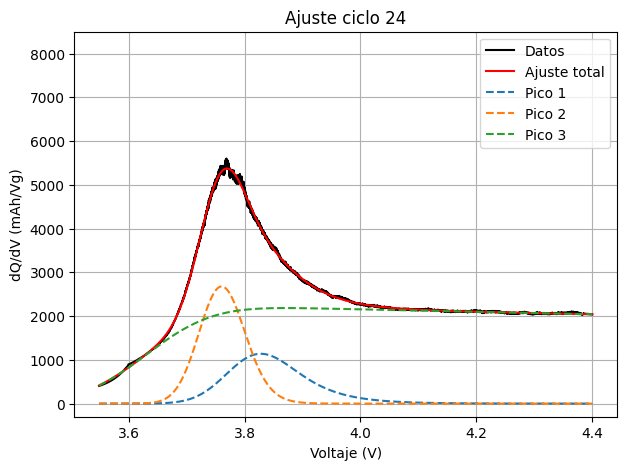

Ajustando ciclo 27...


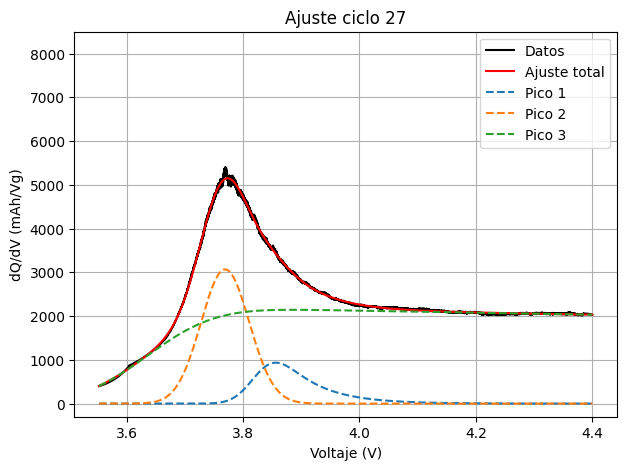

Ajustando ciclo 30...


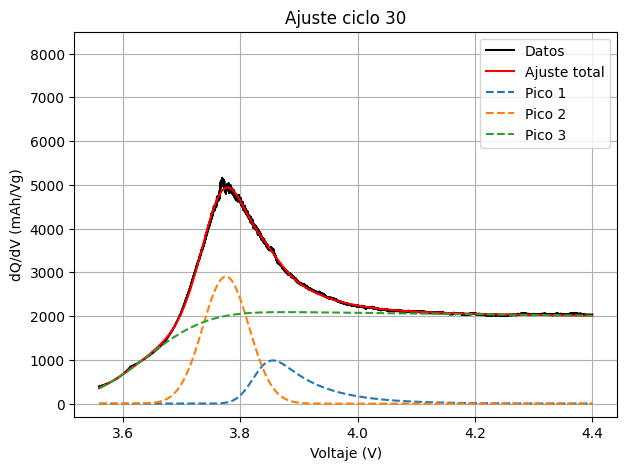

Ajustando ciclo 33...


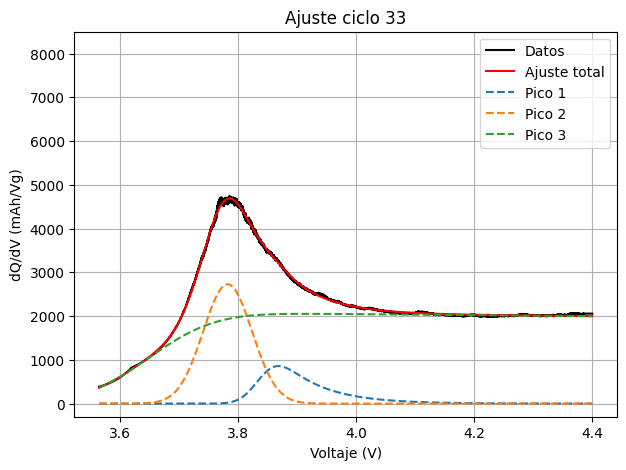

Ajustando ciclo 36...


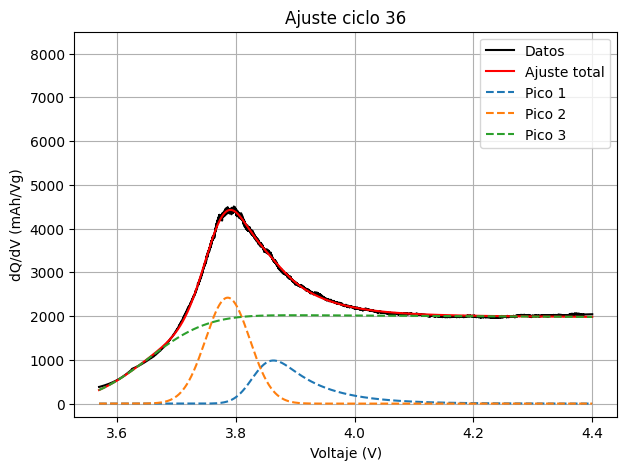

Ajustando ciclo 39...


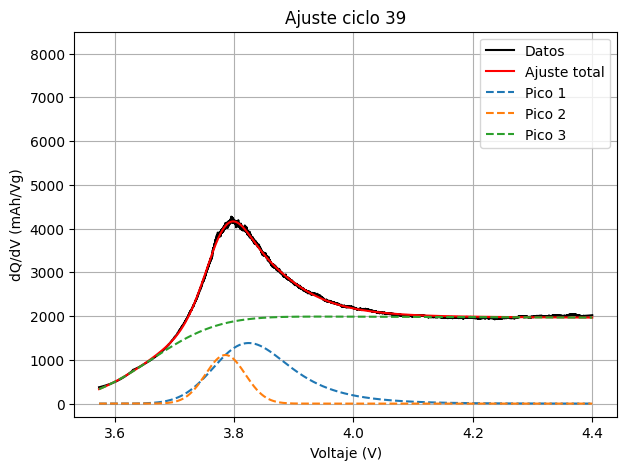

Ajustando ciclo 42...


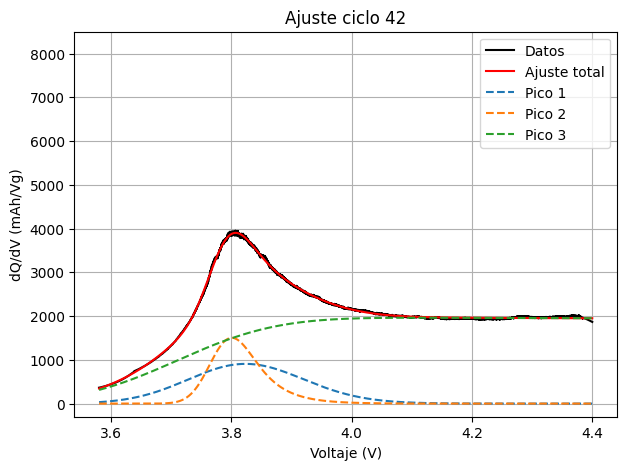

Ajustando ciclo 45...
⚠️ Ajuste del ciclo 45 fallido: Optimal parameters not found: The maximum number of function evaluations is exceeded.. bounds: (array([2.20876587e+01, 3.79033693e-01, 9.08884589e-03, 2.71026224e+00,
       1.59935046e+01, 3.77555753e-01, 2.98446601e-03, 2.44475261e+00,
       8.11984353e+03, 3.71032925e-01, 1.30223518e-02, 2.44329452e-03]), array([4.19665516e+02, 7.20164017e+00, 1.72688072e-01, 5.14949826e+01,
       3.03876587e+02, 7.17355930e+00, 5.67048542e-02, 4.64502996e+01,
       1.54277027e+05, 7.04962557e+00, 2.47424684e-01, 4.64225958e-02])), p0: [2.20876587e+02 3.79033693e+00 9.08884589e-02 2.71026224e+01
 1.59935046e+02 3.77555753e+00 2.98446601e-02 2.44475261e+01
 8.11984353e+04 3.71032925e+00 1.30223518e-01 2.44329452e-02]
Ajustando ciclo 48...


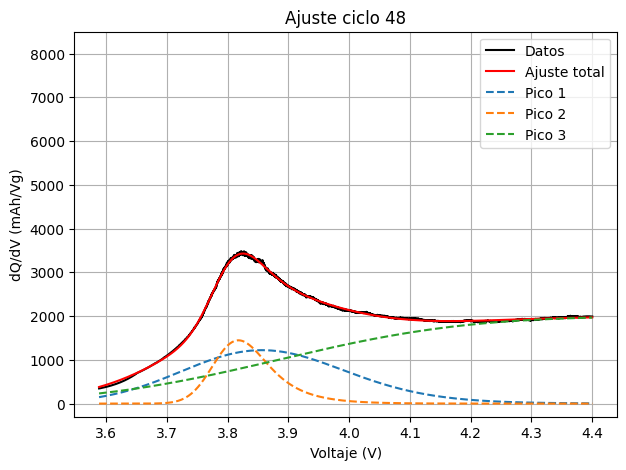

Ajustando ciclo 51...


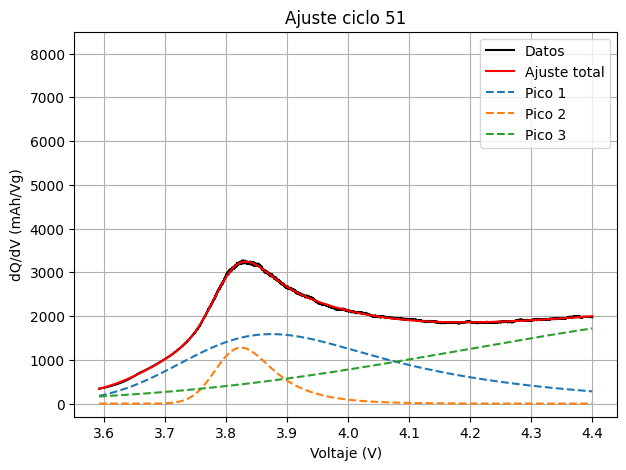

Ajustando ciclo 54...


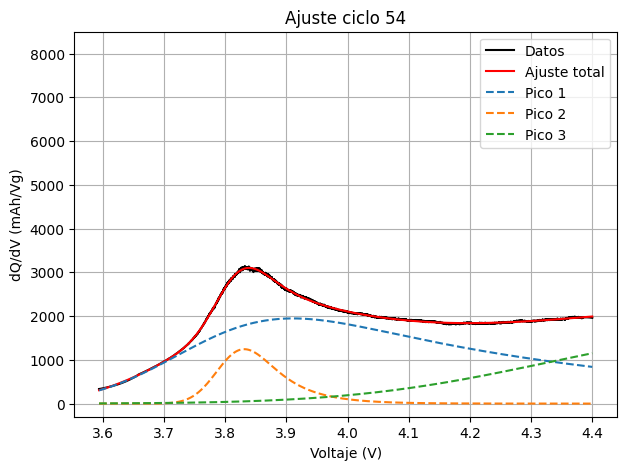

Ajustando ciclo 57...


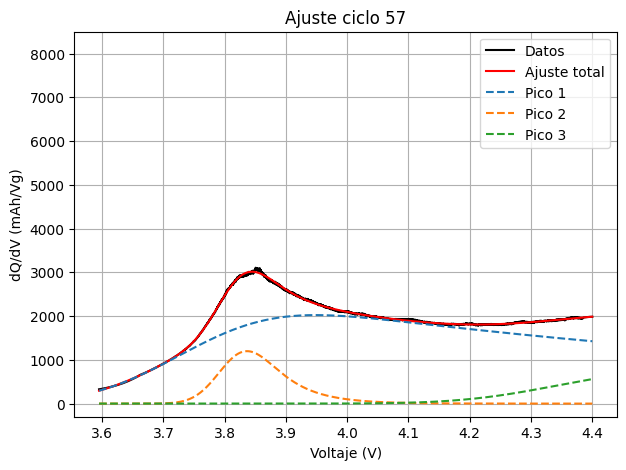

Ajustando ciclo 60...


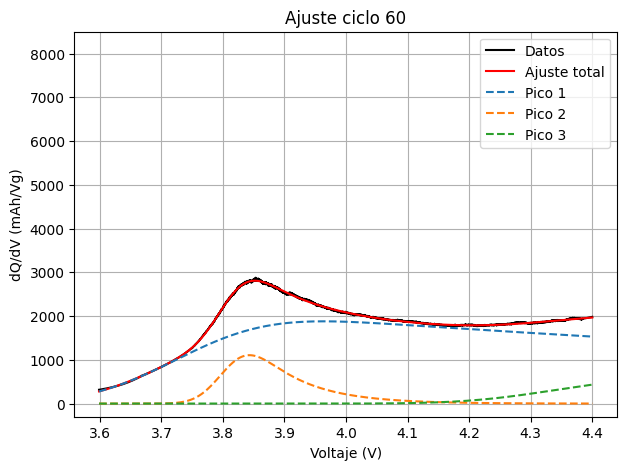

Ajustando ciclo 63...


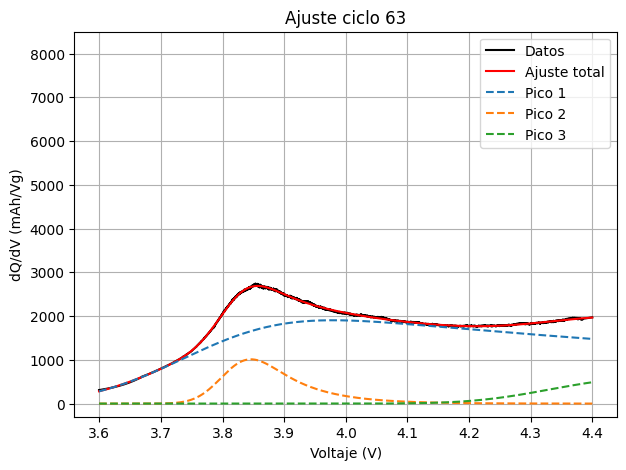

Ajustando ciclo 66...


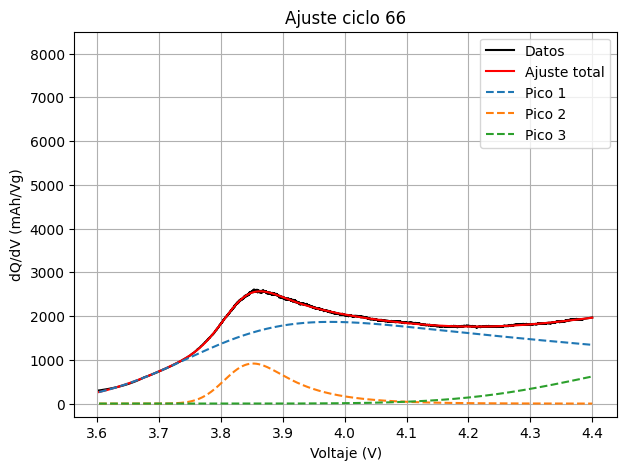

Ajustando ciclo 69...


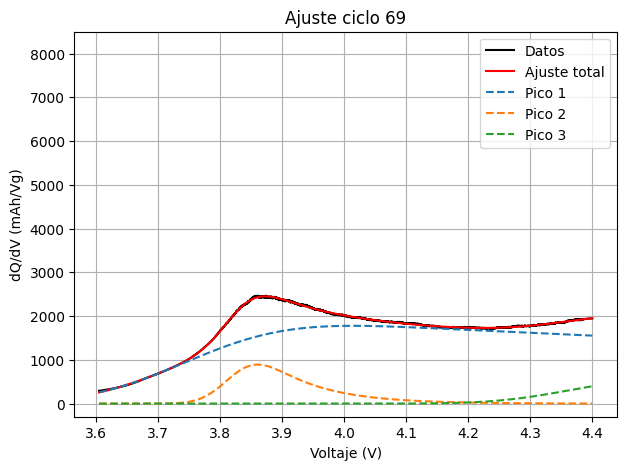

Ajustando ciclo 72...


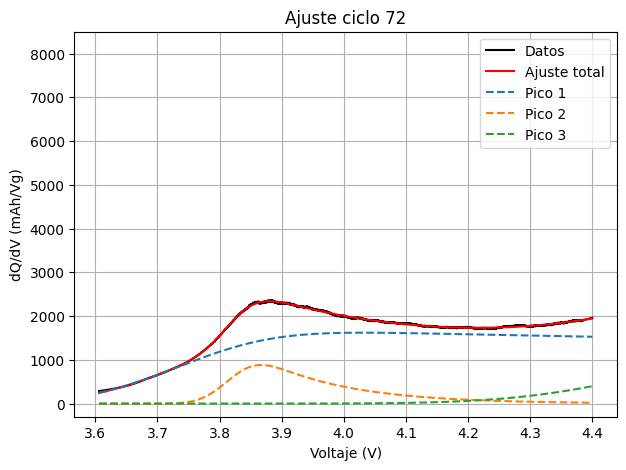

Ajustando ciclo 75...


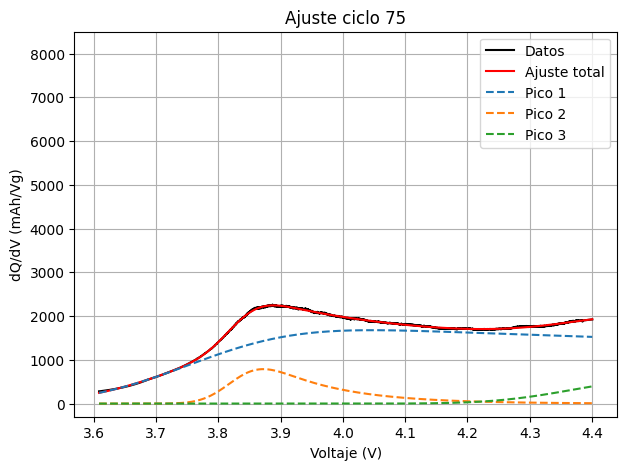

Ajustando ciclo 78...


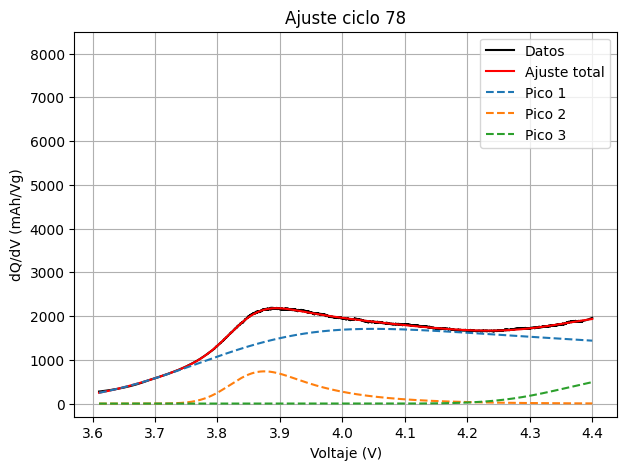

Ajustando ciclo 81...


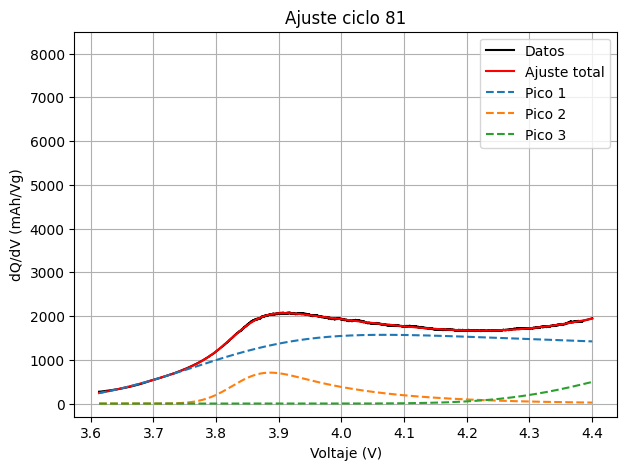

Ajustando ciclo 84...


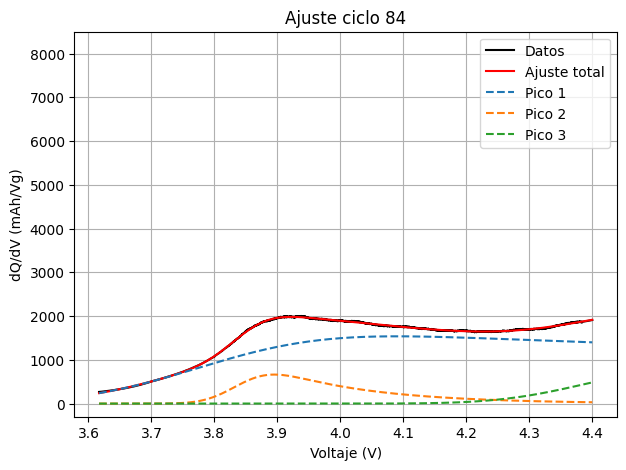

Ajustando ciclo 87...


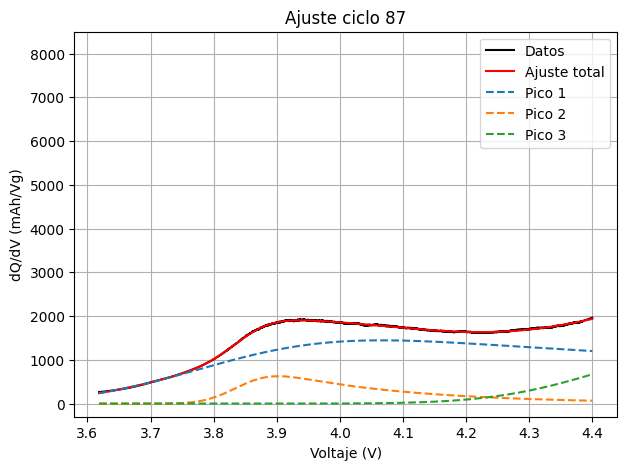

Ajustando ciclo 90...


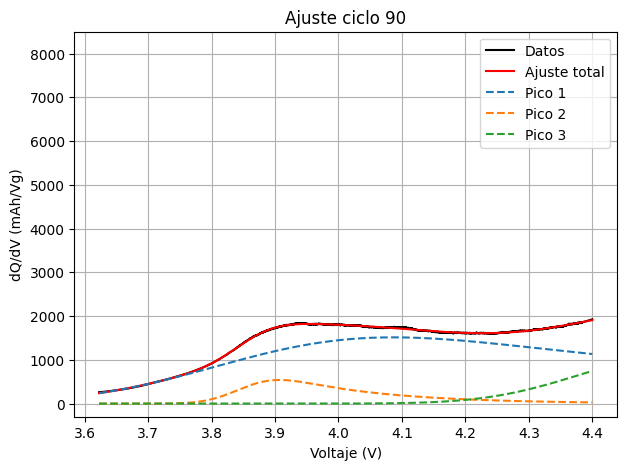

Ajustando ciclo 93...


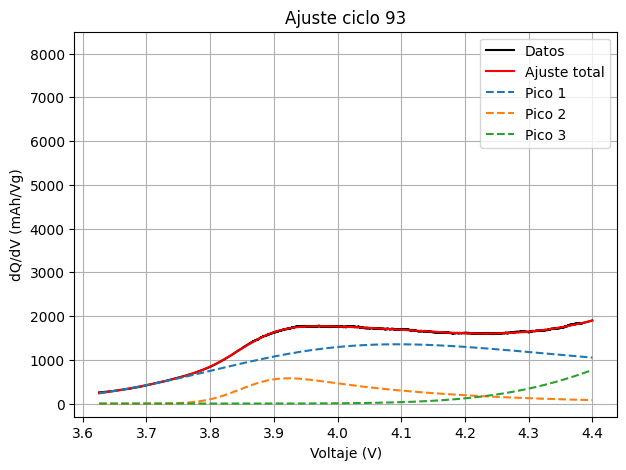

Ajustando ciclo 96...


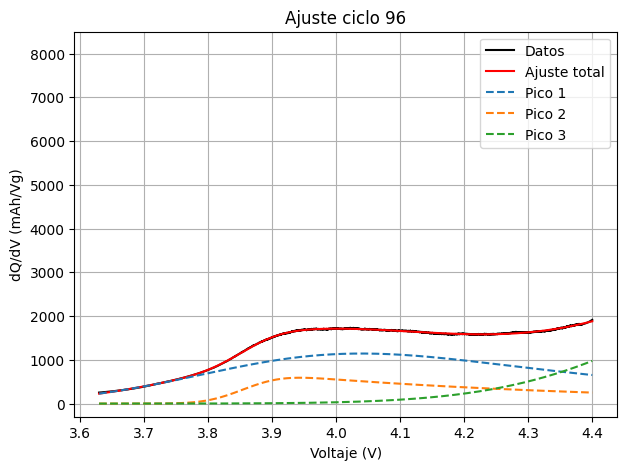

Ajustando ciclo 99...


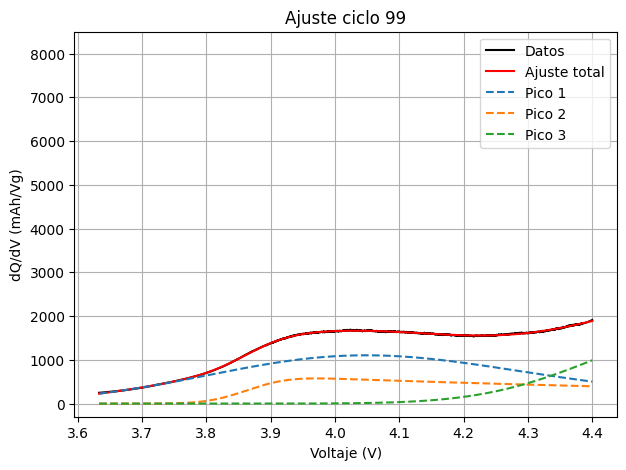

Ajustando ciclo 102...


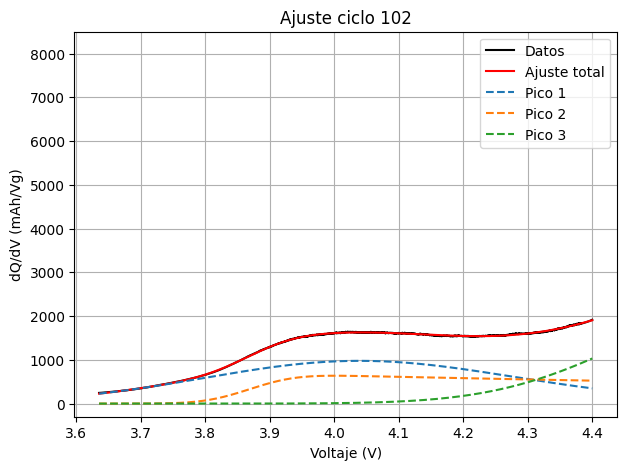

Ajustando ciclo 105...


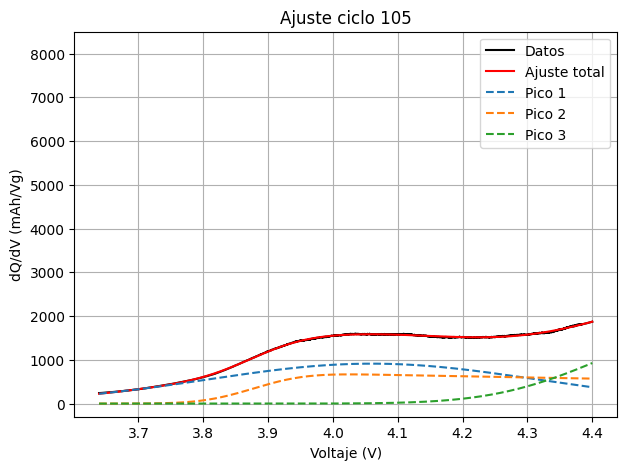

Ajustando ciclo 108...


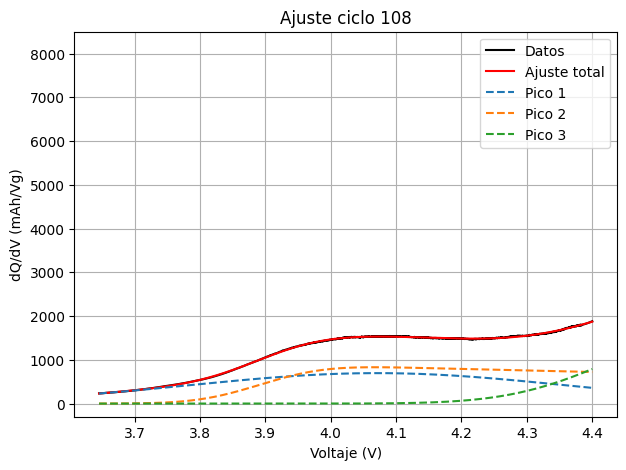

Ajustando ciclo 111...


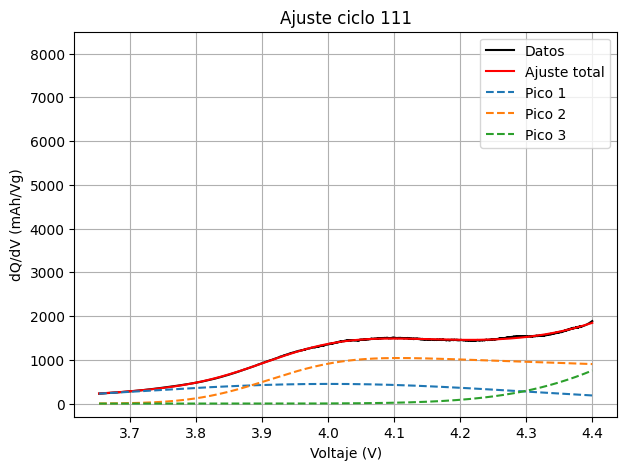

Ajustando ciclo 114...


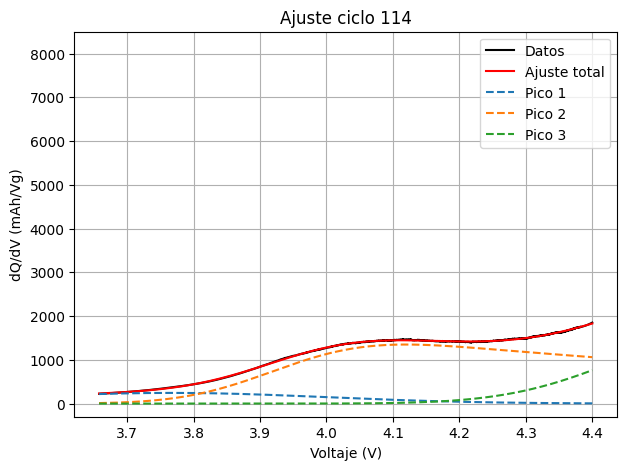

Ajustando ciclo 117...


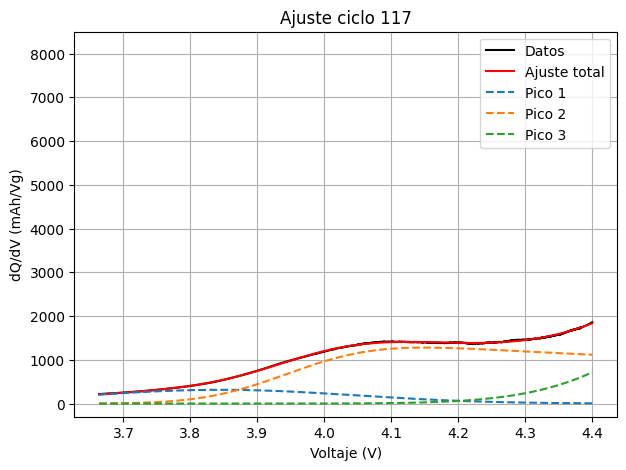

Ajustando ciclo 120...


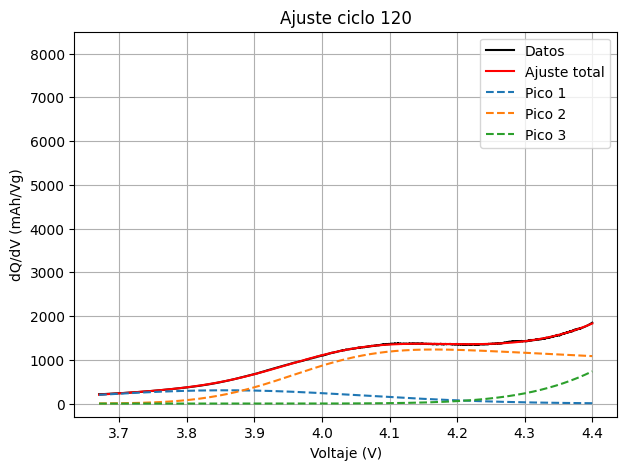

Ajustando ciclo 123...


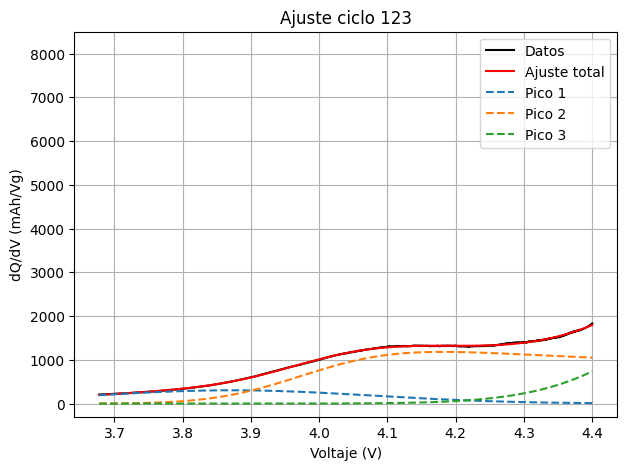

Ajustando ciclo 126...


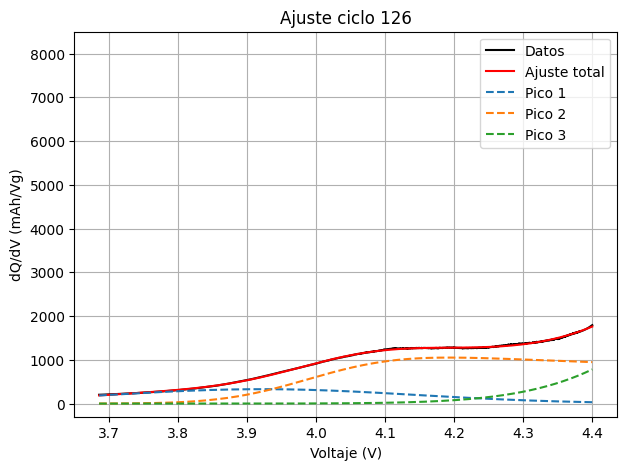

Ajustando ciclo 129...


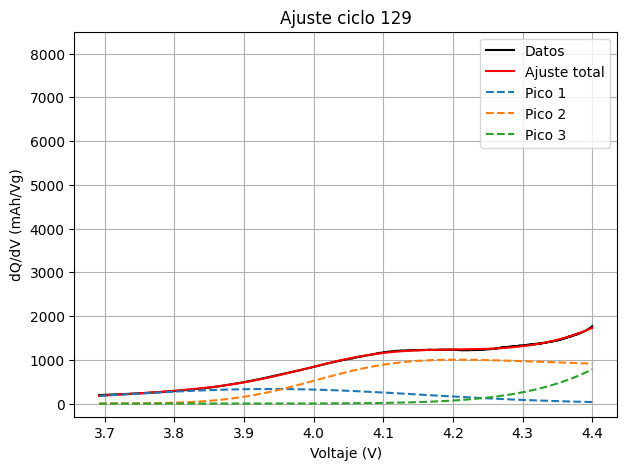

Ajustando ciclo 132...


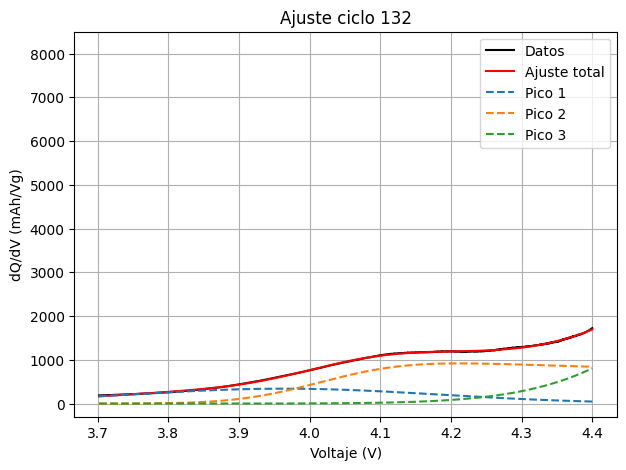

Ajustando ciclo 135...


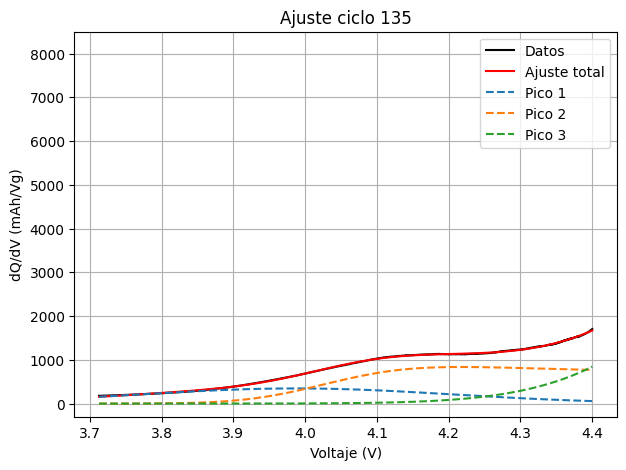

Ajustando ciclo 138...


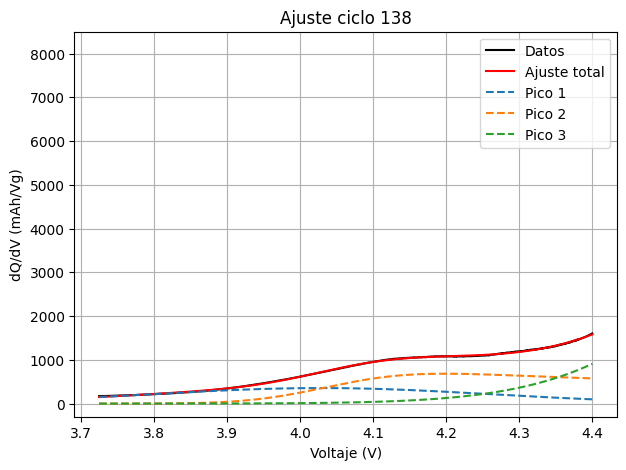

Ajustando ciclo 141...


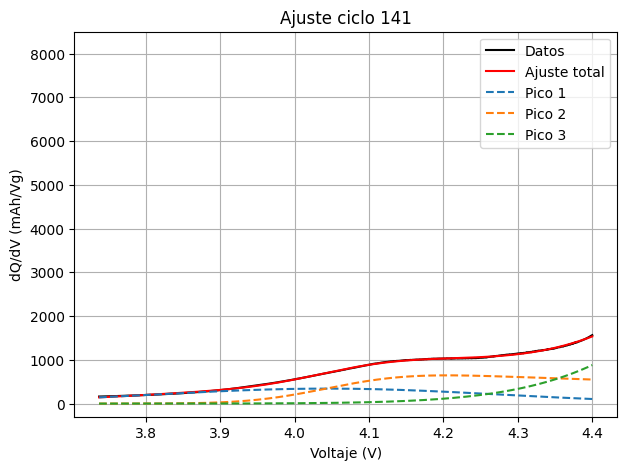

Ajustando ciclo 144...


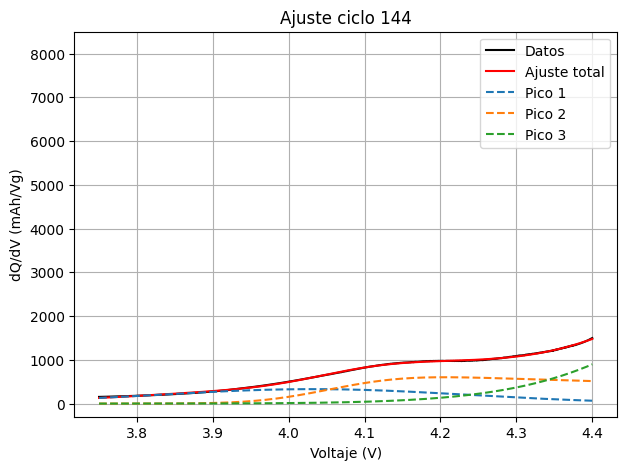

Ajustando ciclo 147...


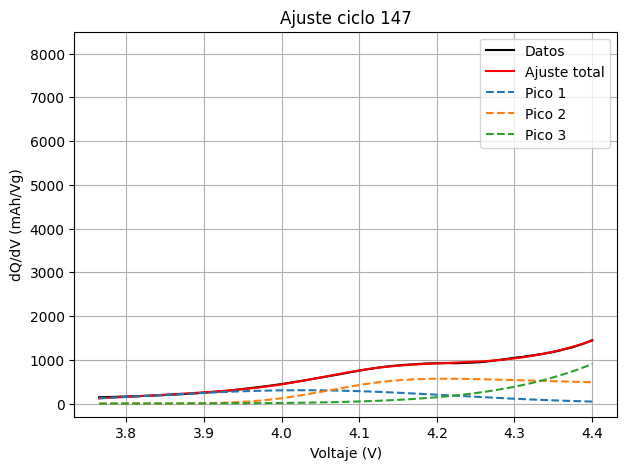

Ajustando ciclo 150...


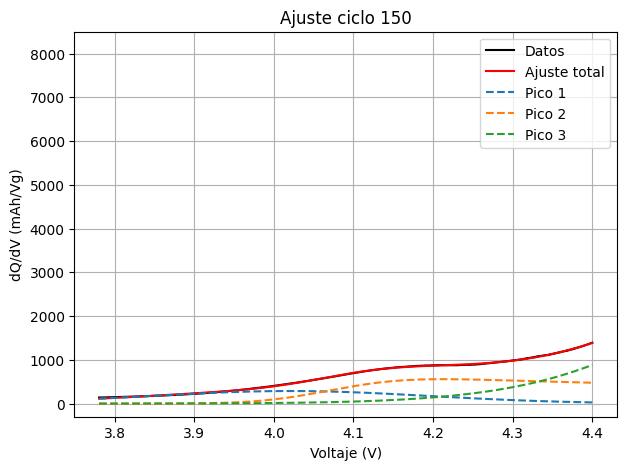

Ajustando ciclo 153...


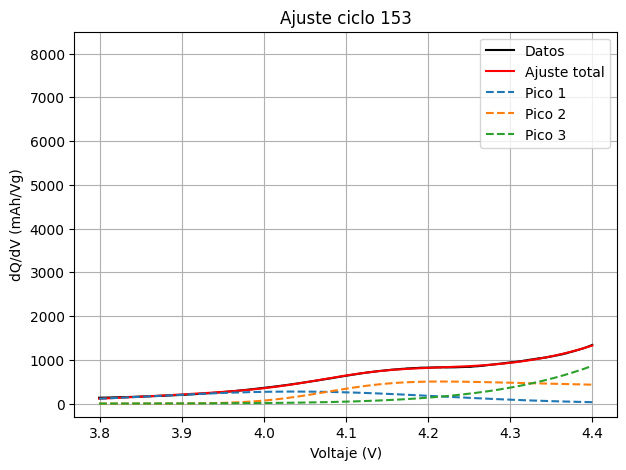

Ajustando ciclo 156...


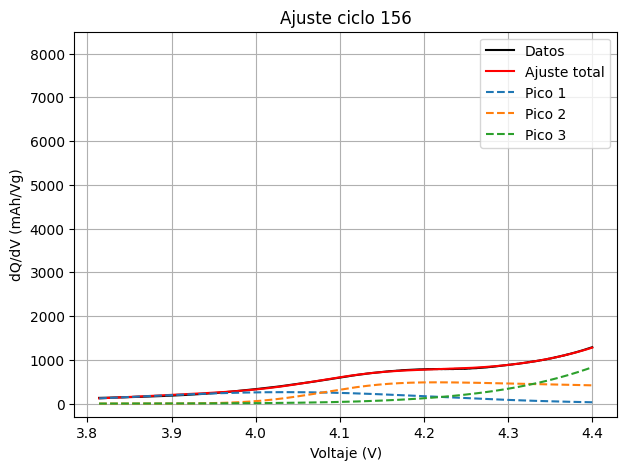

Ajustando ciclo 159...


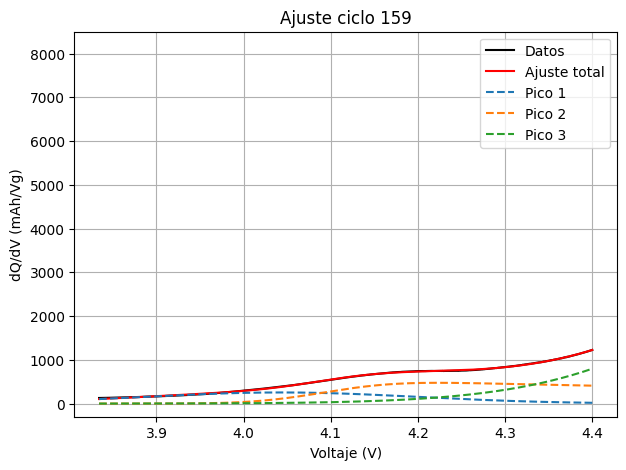

Ajustando ciclo 162...


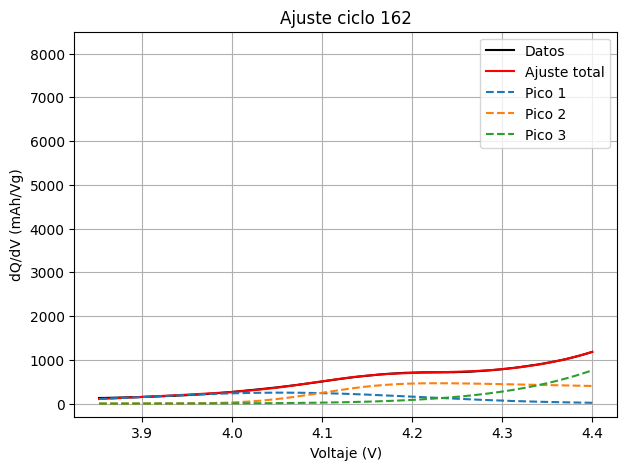

Ajustando ciclo 165...


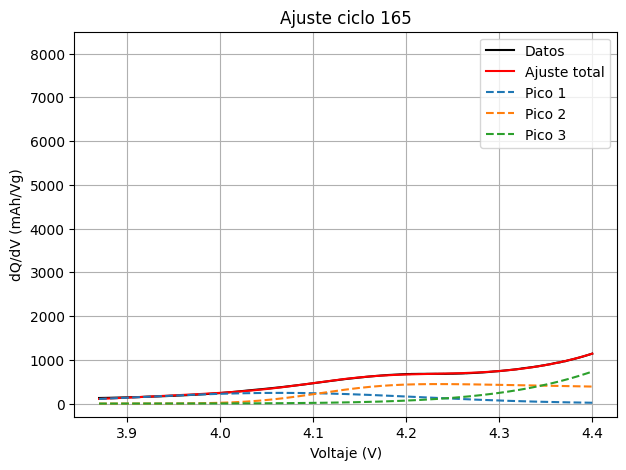

Ajustando ciclo 168...


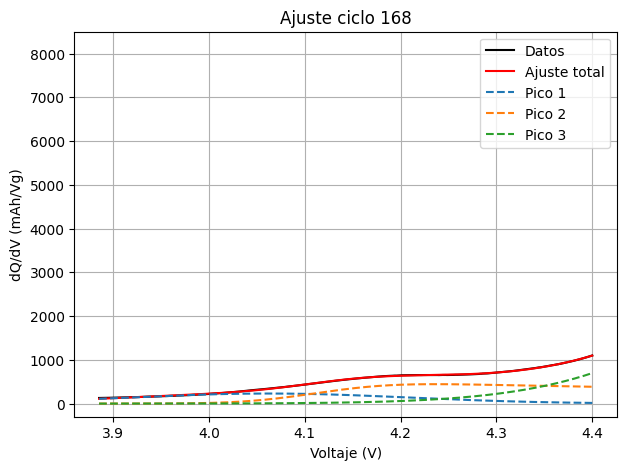

Ajustando ciclo 171...


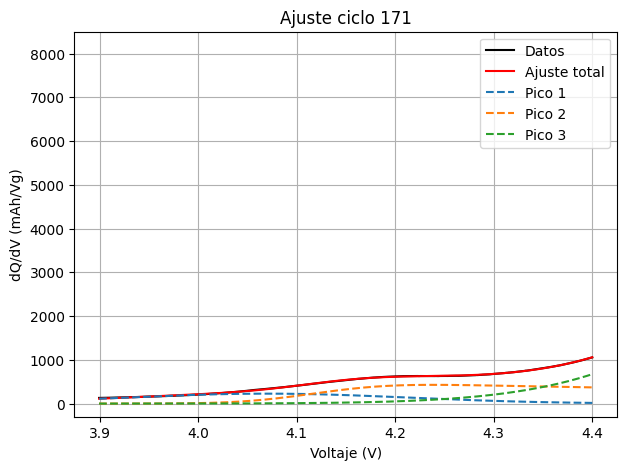

Ajustando ciclo 174...


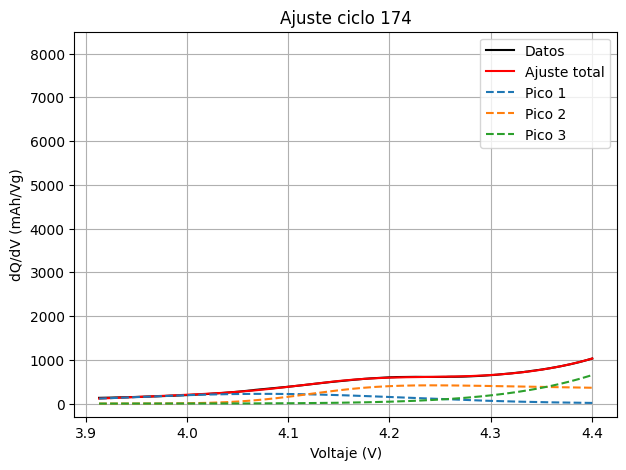

Ajustando ciclo 177...


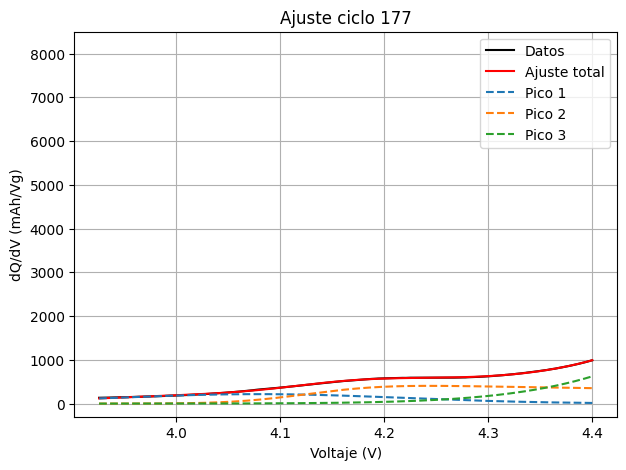

Ajustando ciclo 180...


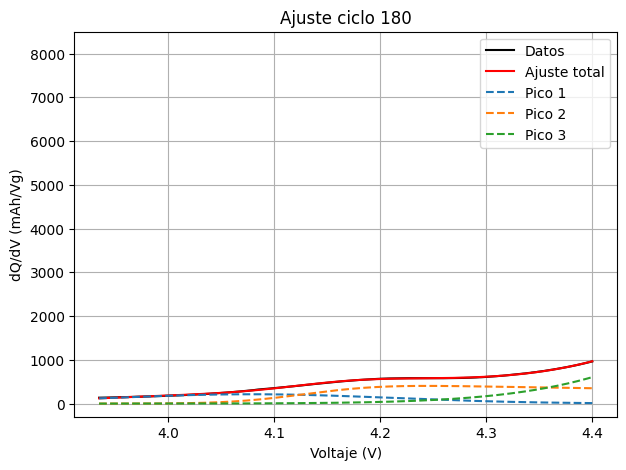

Ajustando ciclo 183...


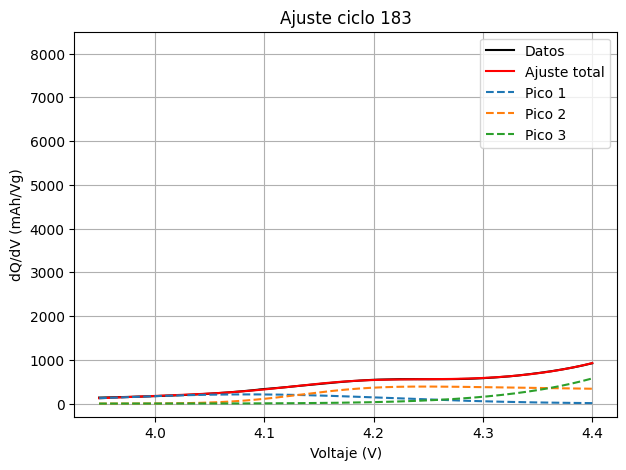

Ajustando ciclo 186...


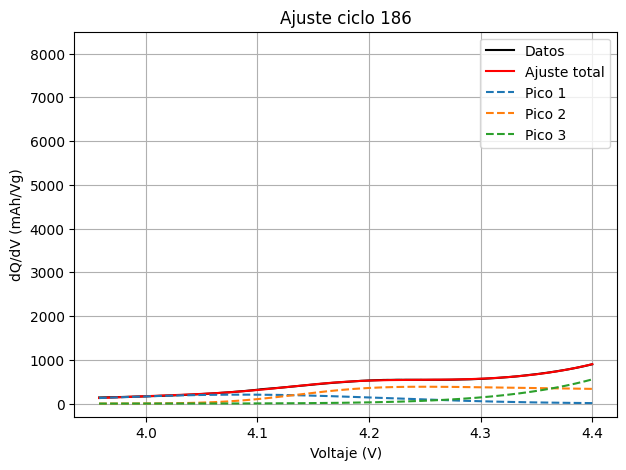

Ajustando ciclo 189...


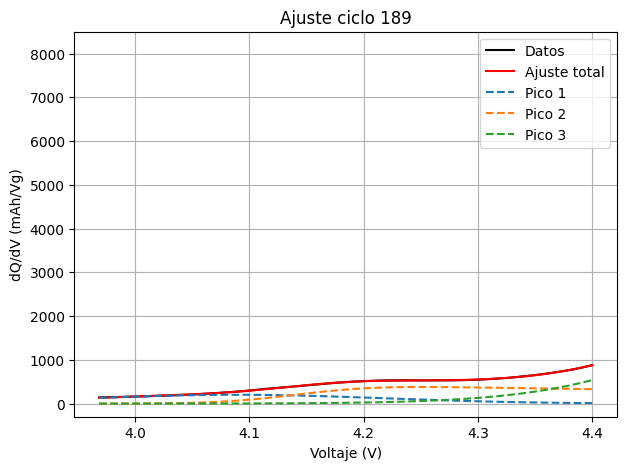

Ajustando ciclo 192...


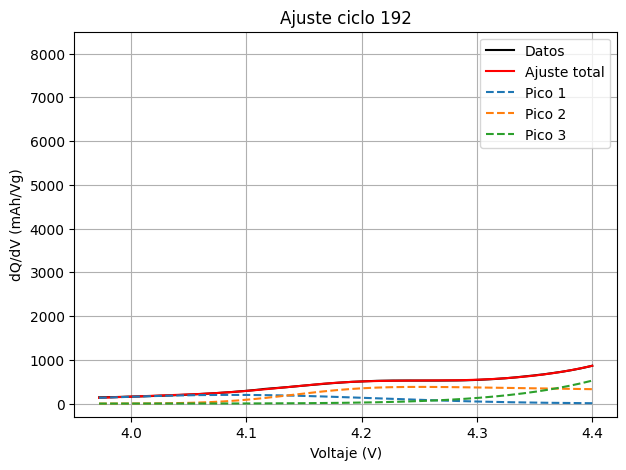

Ajustando ciclo 195...


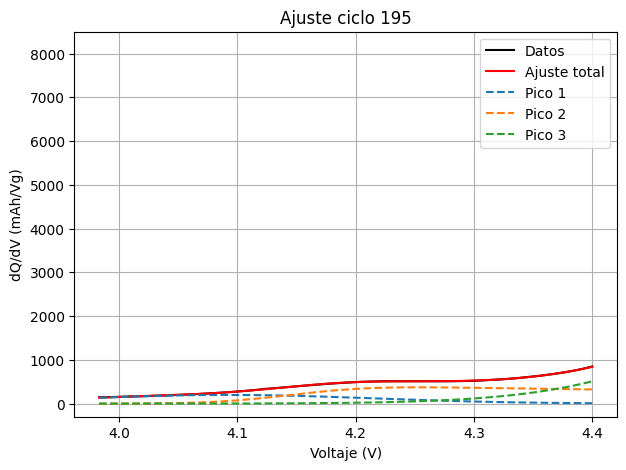

✅ Ajustes terminados. Resultados guardados en '../output/parametros_ajustes_NMC-10-cada3_EMG_2025-11-28_14-10-51.csv'


,a1,mu1,sigma1,lambda1,a2,mu2,sigma2,lambda2,a3,mu3,sigma3,lambda3
1,1650.000000,3.609651,0.046406,0.701222,875.037712,3.709766,0.019251,8.631667,4.346739e+02,4.162365,0.180408,60.653825
3,1911.040934,3.621140,0.075217,1.332322,676.067354,3.710766,0.020585,9.701342,7.198353e+02,4.228956,0.218738,6.065383
6,1281.205733,3.641242,0.093934,2.530602,575.345920,3.713914,0.024923,12.465292,1.367687e+03,4.204390,0.287749,3.942439
9,617.455551,3.634996,0.080151,4.283914,641.152933,3.713708,0.026880,10.724721,2.598602e+03,4.005093,0.297966,1.481357
12,391.752003,3.635527,0.080270,8.139398,705.584722,3.715147,0.028631,9.439896,4.842788e+03,3.890274,0.227912,0.553510
...,...,...,...,...,...,...,...,...,...,...,...,...
183,68.688572,4.076071,0.129999,119.512193,426.142361,4.136028,0.054124,1.049164,1.714269e+06,4.778305,0.195072,0.012787
186,67.136210,4.077868,0.130445,121.789606,416.598465,4.138541,0.054224,1.064315,1.738456e+06,4.767728,0.188394,0.012498
189,65.051304,4.081061,0.128211,127.988833,394.119812,4.142492,0.053437,1.113448,1.700306e+06,4.747646,0.180537,0.011657
192,62.789860,4.079497,0.125621,131.385153,383.719586,4.143514,0.053026,1.151831,1.679733e+06,4.739593,0.179592,0.010673


In [21]:
# --- Ajuste de múltiples ciclos ---

# ---- Elegir ciclos del loop, nombre del .csv, parámetros iniciales y bounds ------------------
nombre_ajuste = f'{nombre}_EMG_{timestamp}'
ciclos_ajustar = [c for c in ciclos_sel_todos] #if 0 <= c <= 900]
ciclos_graficar = [c for c in ciclos_ajustar]# if c == 1 or c % 3 == 0]

# Elegir p_ini (son los parametros iniciales del primer ajuste)
param_guess = [(1500, 3.56, 5.15620917e-02, 6.37474532e-01),
                ( 7.95488829e+02, 3.71021028e+00, 1.75009098e-02, 8.04841702e+00),
                #(2.12087703e+02, 3.99801493e+00, 2.48713898e-02, 5.36805383e-01),
                (3.95158095e+02, 4.30488376e+00, 2.00453430e-01, 5.51398592e+01)
                ]
p_ini_emg = [x for t in param_guess for x in t]  # aplanado

# Elegir bounds_ini manualmente (son los bounds del primer ajuste)
lb, ub = [], []
for (a0, mu0, sigma0, lam0) in param_guess:
    lb += [0.9*a0, 0.9*mu0, 0.9*sigma0, 0.9*lam0]
    ub += [1.1*a0, 1.1*mu0, 1.1*sigma0, 1.1*lam0]
bounds_ini_emg = (lb, ub)

# Elegir bounds del loop (son los bounds del resto de los ajustes)
cfg_bounds = {
    'perc_a': 0.9,
    'perc_mu': 0.9,
    'perc_sigma': 0.9,
    'perc_lambda': 0.9#,
    #'restricciones_mu': {2: (3.5, 4.45), 3: (3.5, 4.45)}
}
# ----------------------------------------------------------------------------------------------

parametros, covs = ft.fitloop_emg(
    diccio_todos,
    ciclos=ciclos_ajustar,
    p_ini_emg=p_ini_emg,
    bounds_ini_emg=bounds_ini_emg,
    ciclos_grafico=ciclos_graficar,
    cfg_bounds=cfg_bounds
)
ft.guardar_parametros_emg(parametros, ciclos_sel_todos, nombre_ajuste)